# Signals in the Noise

## An observed traffic-quality walkthrough

I built this notebook to show the investigation in the order I actually think through it: start with the limits of the data, establish a time-safe baseline, compare expected and observed outcomes, and only then decide what deserves review.

The source is Criteo's public attribution dataset. It has real advertising-event structure, clicks, conversion-linked impressions, campaign IDs, anonymous context, and transformed cost. It does **not** have invalid-traffic labels. I therefore use the word *unusual* deliberately. Nothing in this notebook proves that a campaign or person committed abuse.

## 1. Recreate or reuse the pipeline outputs

The notebook looks for the pipeline's processed files first. On a fresh clone it runs the same end-to-end pipeline used by the project: download a chronological sample, validate it, build SQLite and SQL features, fit both analysis tracks, and write the reports. Set `SIGNALS_DATA_DIR` if the runtime data should live outside the repository.

In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import SVG, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = Path(os.environ.get("SIGNALS_DATA_DIR", PROJECT_ROOT / "data"))
SAMPLE_ROWS = 500_000
score_path = DATA_DIR / "processed" / "observed_quality_scored_windows.csv"

if not score_path.exists():
    from src.pipeline import run
    run(rows=SAMPLE_ROWS, data_dir_value=str(DATA_DIR))

print(f"Project: {PROJECT_ROOT}")
print(f"Runtime data: {DATA_DIR}")
print(f"Observed score table: {score_path}")

Project: C:\Users\pandy\Documents\Codex\2026-08-02\inimum-qualifications-bachelor-s-degree-or\work\publish_data_science_repo\End to end data science project\signals-in-the-noise-ad-traffic-investigation
Runtime data: C:\Users\pandy\Documents\Codex\2026-08-02\inimum-qualifications-bachelor-s-degree-or\work\signals_data
Observed score table: C:\Users\pandy\Documents\Codex\2026-08-02\inimum-qualifications-bachelor-s-degree-or\work\signals_data\processed\observed_quality_scored_windows.csv


In [2]:
def line_chart_svg(labels, expected, actual, title, y_label):
    # Compact inline SVG chart; see the generated output below.
    from src.notebook_charts import line_chart_svg as build_chart
    return build_chart(labels, expected, actual, title, y_label)

def risk_histogram_svg(train, test):
    from src.notebook_charts import risk_histogram_svg as build_chart
    return build_chart(train, test)

def case_rates_svg(labels, observed, expected):
    from src.notebook_charts import case_rates_svg as build_chart
    return build_chart(labels, observed, expected)

## 2. Keep the two questions separate

The project contains a controlled stress test, but this notebook focuses on the observed-only track. Every campaign window touched by a simulated row is removed before these models are fitted or scored.

The unit of analysis is a campaign in a 30-minute window. That gives me enough behavior to examine volume, click rate, conversion rate, returning-user concentration, source concentration, timing, and relative cost exposure.

In [3]:
reports_dir = PROJECT_ROOT / "reports"
processed_dir = DATA_DIR / "processed"

scored = pd.read_csv(processed_dir / "observed_quality_scored_windows.csv")
observed_features = pd.read_csv(processed_dir / "observed_campaign_quality.csv")
queue = pd.read_csv(reports_dir / "observed_review_queue.csv")
calibration = pd.read_csv(reports_dir / "observed_calibration.csv")
metrics = json.loads((reports_dir / "observed_model_metrics.json").read_text())
run_summary = json.loads((reports_dir / "run_summary.json").read_text())

overview = pd.DataFrame(
    {
        "stage": ["Source sample", "Combined stress-test stream", "All campaign windows", "Observed-only windows", "Held-out review cases"],
        "rows_or_windows": [run_summary["source_rows"], run_summary["combined_events"], run_summary["campaign_windows"], run_summary["observed_only_windows"], len(queue)],
    }
)
overview

stage,rows_or_windows
Source sample,500000
Combined stress-test stream,512470
All campaign windows,15157
Observed-only windows,15131
Held-out review cases,11


In [4]:
quality_check = pd.DataFrame(
    {
        "check": ["Observed-only windows", "Unique campaigns", "Earliest timestamp", "Latest timestamp", "Missing expected CTR", "Missing risk score"],
        "value": [len(scored), scored["campaign"].nunique(), int(scored["window_start"].min()), int(scored["window_start"].max()), int(scored["expected_ctr"].isna().sum()), int(scored["quality_risk_score"].isna().sum())],
    }
)
quality_check

check,value
Observed-only windows,15131
Unique campaigns,631
Earliest timestamp,0
Latest timestamp,73800
Missing expected CTR,0
Missing risk score,0


## 3. Build campaign history without looking ahead

The current window cannot be part of its own baseline. In SQL I use the campaign's previous 20 available windows, ending at `1 PRECEDING`. A new campaign falls back to global values calculated from the training period, and I retain `history_windows` so limited context remains visible to the reviewer.

In [5]:
sql_path = PROJECT_ROOT / "sql" / "04_observed_campaign_quality.sql"
sql_text = sql_path.read_text(encoding="utf-8")
history_lines = [line for line in sql_text.splitlines() if "ROWS BETWEEN" in line or "PARTITION BY" in line or "ORDER BY window_start" in line]
print("\n".join(history_lines))

        PARTITION BY campaign
        ORDER BY window_start
        ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING
ORDER BY window_start, campaign;


## 4. Replay forward in time

I use the first 70% of the sample timeline to fit expected behavior and keep the last 30% for replay. The click model does not use the window's click outcome. The conversion model can use observed click behavior because it answers a later-stage downstream question.

I evaluate these as probability forecasts. Precision and recall would be inappropriate here because the source has no real abuse label.

In [6]:
split = metrics["data_split"]
split_table = pd.DataFrame(
    {
        "period": ["Train", "Held out"],
        "windows": [split["train_windows"], split["test_windows"]],
        "campaigns": [split["train_campaigns"], split["test_campaigns"]],
    }
)
split_table

period,windows,campaigns
Train,9229,605
Held out,5902,611


## 5. Check calibration before looking at anomalies

The average expected rates are close to what happened in the held-out period, but averages can hide poor ranking. I therefore compare expected and observed rates within prediction deciles. A useful model should generally assign higher observed rates to higher expected-rate groups.

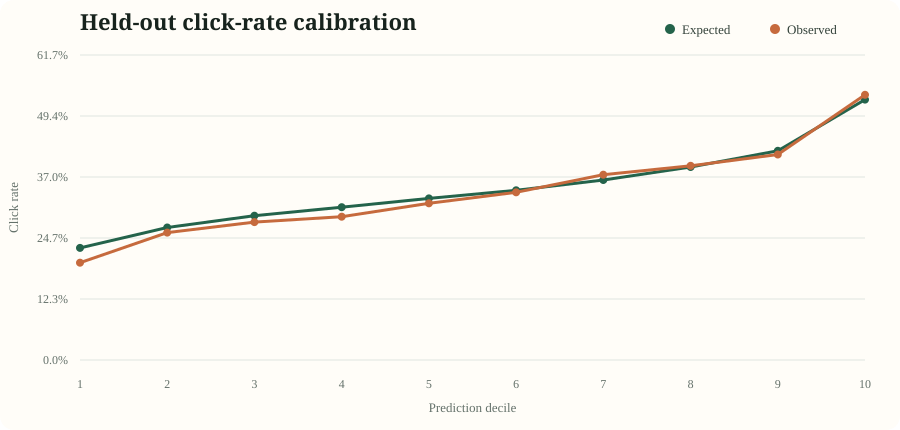

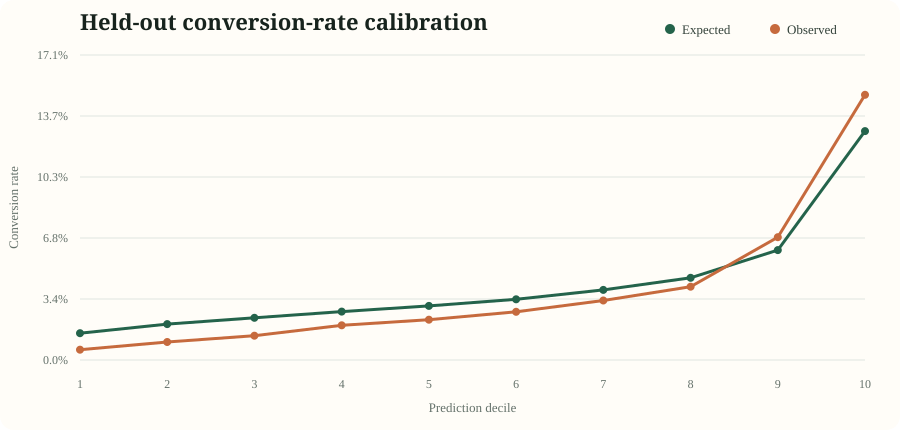

model,observed_rate,mean_expected_rate,weighted_mean_absolute_error,weighted_brier_score,weighted_log_loss
Click rate,0.350027,0.355958,0.063759,0.007769,0.631221
Conversion rate,0.048204,0.049720,0.026554,0.001535,0.175489


In [7]:
def calibration_svg(frame, model, title, y_label):
    selected = frame.loc[frame["model"] == model].sort_values("decile")
    return line_chart_svg(
        labels=[str(int(value) + 1) for value in selected["decile"]],
        expected=selected["mean_expected_rate"].to_numpy(),
        actual=selected["actual_rate"].to_numpy(),
        title=title,
        y_label=y_label,
    )

display(SVG(calibration_svg(calibration, "click_rate", "Held-out click-rate calibration", "Click rate")))
display(SVG(calibration_svg(calibration, "conversion_rate", "Held-out conversion-rate calibration", "Conversion rate")))

model_checks = pd.DataFrame(
    [
        {"model": "Click rate", **metrics["expected_click_rate_test"]},
        {"model": "Conversion rate", **metrics["expected_conversion_rate_test"]},
    ]
)[["model", "observed_rate", "mean_expected_rate", "weighted_mean_absolute_error", "weighted_brier_score", "weighted_log_loss"]]
model_checks

## 6. Turn prediction errors into a review priority

I standardize click and conversion residuals by their expected binomial variation. The final quality score combines click surprise, conversion shortfall, campaign-relative volume, user/source concentration, and transformed cost exposure. Each component is first converted to a percentile against the training period.

That final percentile is a ranking device. It is not a probability of fraud or a statement about intent.

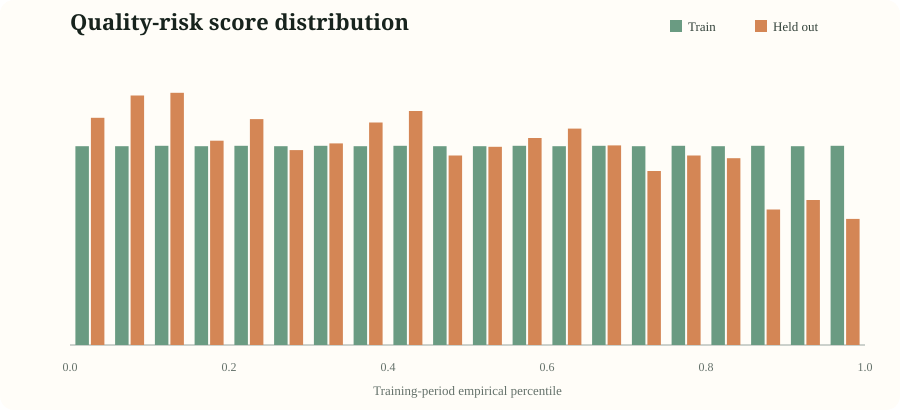

window_start,campaign,quality_risk_score,click_deviation_z,conversion_deviation_z,volume_change_ratio
64800,2946551,0.9948,2.3843,-1.9871,1.8282
72000,1869939,0.9948,1.6893,-1.4608,1.5951
52200,12843317,0.9943,-1.7516,-1.1211,1.4225
70200,5044698,0.9941,2.4931,-0.9948,1.4857
61200,83677,0.9930,1.5964,-1.3340,1.8444
52200,12843316,0.9920,1.7749,-1.2897,1.8667
52200,30535894,0.9920,2.5991,-0.7391,1.3051
64800,17686799,0.9913,-2.9285,-1.3255,1.1032
70200,2576437,0.9908,3.3605,-2.3981,1.4746
68400,17686799,0.9905,-3.5674,-1.9797,1.1034


In [8]:
train_scores = scored.loc[scored["data_period"] == "train", "quality_risk_score"].to_numpy()
test_scores = scored.loc[scored["data_period"] == "test", "quality_risk_score"].to_numpy()
display(SVG(risk_histogram_svg(train_scores, test_scores)))

top_residuals = scored.loc[scored["data_period"] == "test"].nlargest(10, "quality_risk_score")
top_residuals[["window_start", "campaign", "quality_risk_score", "click_deviation_z", "conversion_deviation_z", "volume_change_ratio"]]

## 7. Keep the operational output small and neutral

I use a 99% training-period cutoff and cap the published queue at 30 windows. In this replay, 11 held-out windows crossed the boundary. The queue intentionally excludes every evaluation label and supports only `monitor` or `review_traffic_quality`.

In [9]:
queue_view = queue[
    ["window_start", "campaign", "quality_risk_score", "clicks", "expected_clicks", "conversions", "expected_conversions", "evidence_summary"]
].copy()
queue_view[["quality_risk_score", "expected_clicks", "expected_conversions"]] = queue_view[
    ["quality_risk_score", "expected_clicks", "expected_conversions"]
].round(3)
queue_view

window_start,campaign,quality_risk_score,clicks,expected_clicks,conversions,expected_conversions,evidence_summary
64800,2946551,0.995,60,49.058,2,7.581,clicks were higher than the expected range
72000,1869939,0.995,12,8.669,0,2.551,activity was concentrated among returning user IDs
52200,12843317,0.994,13,17.793,0,1.852,activity was concentrated among returning user IDs
70200,5044698,0.994,52,39.042,2,4.245,clicks were higher than the expected range
61200,83677,0.993,27,20.808,0,2.441,several moderate departures combined into an unusual quality profile
52200,30535894,0.992,48,36.322,4,5.873,clicks were higher than the expected range
52200,12843316,0.992,20,14.991,1,3.630,the campaign had limited historical context
64800,17686799,0.991,123,153.134,9,14.077,clicks were lower than the expected range; the window carried relatively high transformed cost exposure
70200,2576437,0.991,85,63.404,1,8.073,clicks were higher than the expected range; conversion-linked impressions fell below expectation
68400,17686799,0.990,113,149.468,6,13.421,clicks were lower than the expected range; the window carried relatively high transformed cost exposure


## 8. Open one case before making any judgment

The score gets a case onto my desk; it does not close the investigation. I compare observed and expected outcomes, read the evidence summary, and write down plausible legitimate explanations before considering any restrictive step.

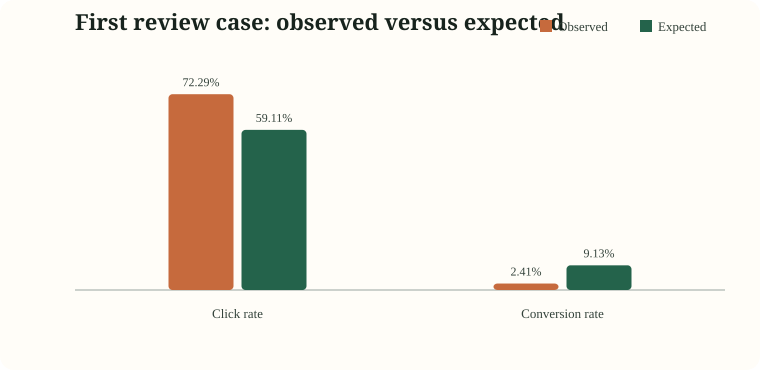

field,value
Campaign,2946551
Window start,64800
Quality-risk percentile,0.9948
Earlier campaign windows,20
Evidence,clicks were higher than the expected range


In [10]:
case = queue.iloc[0]
display(
    SVG(
        case_rates_svg(
            labels=["Click rate", "Conversion rate"],
            observed=np.array([case["ctr"], case["conversion_rate"]]),
            expected=np.array([case["expected_ctr"], case["expected_conversion_rate"]]),
        )
    )
)

case_summary = pd.DataFrame(
    {
        "field": ["Campaign", "Window start", "Quality-risk percentile", "Earlier campaign windows", "Evidence"],
        "value": [int(case["campaign"]), int(case["window_start"]), round(case["quality_risk_score"], 4), int(case["history_windows"]), case["evidence_summary"]],
    }
)
case_summary

## 9. What I concluded

- The held-out click rate was **35.00%**, compared with **35.60%** expected.
- The held-out conversion-linked impression rate was **4.82%**, compared with **4.97%** expected.
- **11** held-out windows crossed the review boundary.
- Campaign history made the residuals more meaningful than a single global outlier rule.
- The public fields are sufficient to prioritize questions, but not to determine intent or enforce a policy.

My next iteration would run the full 30-day file, add day-of-week effects, compare time-based replay with campaign holdout, and measure queue stability under traffic drift. For a real decision, I would also need network, device, user-agent, geography, campaign-change, and longer-horizon outcome evidence.

The notebook's final output is therefore a reviewable lead with a documented uncertainty—not an automatic verdict.